# 🔋 Prédiction de l'État de Santé (SoH) des Batteries : Pipeline d'Entraînement

Ce notebook présente la démarche complète pour entraîner un modèle de Deep Learning (LSTM) capable de prédire l'État de Santé (State of Health - SoH) d'une batterie Lithium-ion à partir de données de cycles de charge/décharge.

## 🎯 Objectifs de ce Notebook
1. **Préparation des données** : Nettoyage, normalisation et création de fenêtres temporelles.
2. **Gestion de l'Anti-Leakage** : Isolation stricte d'une batterie de test (B0018) pour une évaluation impartiale.
3. **Modélisation** : Conception d'une architecture Recurrent Neural Network (LSTM).
4. **Entraînement & Sauvegarde** : Optimisation avec callbacks et persistance du modèle.

---
## 🛠️ 1. Configuration de l'Environnement

In [20]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

sys.path.append(os.path.abspath(".."))
from src.data_loader import load_data
from src.preprocessing import clean_and_sort_data, scale_features
from src.dataset_builder import split_by_battery, temporal_train_val_split
from src.sliding_window import build_sliding_windows
from src.model_lstm import build_lstm_model
from src.logger import setup_logger
from src.cross_validation import run_lobo_cv, train_final_model

logger = setup_logger()

# Chemins
DATA_PATH = "../data/battery_dataset.csv"
SCALER_PATH = "../models/scaler.pkl"
MODEL_PATH = "../models/trained_model.keras"

# Paramètres
FEATURES = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']
TARGET = 'SoH'
TEST_BATTERY_ID = 'B0018'
WINDOW_SIZE = 5
BATCH_SIZE = 64
EPOCHS = 50

---
## 📊 2. Chargement et Audit des Données
On commence par charger le dataset et vérifier sa qualité (valeurs manquantes, types de données).

In [21]:
df_raw = load_data(DATA_PATH)
print(f"📦 Dataset chargé : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes.")

2026-03-20 14:03:53,782 - INFO - Chargement des données depuis : ../data/battery_dataset.csv
2026-03-20 14:03:53,865 - INFO - Données chargées : 29180 lignes, 7 colonnes.


📦 Dataset chargé : 29180 lignes, 7 colonnes.


In [22]:
df_clean = clean_and_sort_data(df_raw)
print("✅ Données triées par batterie et cycle.")

2026-03-20 14:03:53,886 - INFO - Tri des données par battery_id et cycle_number...


✅ Données triées par batterie et cycle.


---
## 🛡️ 3. Stratégie Anti-Fuite (Anti-Leakage)
Une erreur classique en prédiction de batterie est de mélanger les cycles d'une même batterie entre le train et le test. 
Ici, nous isolons **totalement** la batterie `B0018`. Le modèle ne verra jamais aucune de ses mesures durant sa phase d'apprentissage.

In [23]:
train_val_df, test_df = split_by_battery(df_clean, test_battery_id=TEST_BATTERY_ID)
print(f"🏠 Train/Val : {train_val_df['battery_id'].unique()} | {train_val_df.shape[0]} samples")
print(f"🧪 Test (Exclu) : {test_df['battery_id'].unique()} | {test_df.shape[0]} samples")

2026-03-20 14:03:53,920 - INFO - Séparation des données : Batterie test => B0018


🏠 Train/Val : ['B0005' 'B0006' 'B0007' 'B0025' 'B0026' 'B0027' 'B0028' 'B0029' 'B0030'
 'B0031' 'B0032' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039' 'B0040' 'B0042'
 'B0043' 'B0044' 'B0046' 'B0047' 'B0048'] | 27100 samples
🧪 Test (Exclu) : ['B0018'] | 2080 samples


Nous effectuons également un **split temporel** sur les batteries d'entraînement : les premiers cycles servent au training, les derniers à la validation. C'est la méthode la plus réaliste pour simuler un système en production.

In [24]:
train_df, val_df = temporal_train_val_split(train_val_df, val_ratio=0.2)
print(f"📈 Train : {train_df.shape[0]} samples")
print(f"📡 Val : {val_df.shape[0]} samples")

2026-03-20 14:03:54,094 - INFO - Création validation temporelle avec un ratio de la fin des cycles : 0.2


📈 Train : 22000 samples
📡 Val : 5100 samples


### Normalisation
Le `MinMaxScaler` est fitté **uniquement** sur le set d'entraînement pour éviter toute fuite d'information sur la distribution.

In [25]:
train_df_scaled, scaler = scale_features(train_df, feature_cols=FEATURES, scaler_path=SCALER_PATH)
val_df_scaled = val_df.copy()
val_df_scaled[FEATURES] = scaler.transform(val_df[FEATURES])
test_df_scaled = test_df.copy()
test_df_scaled[FEATURES] = scaler.transform(test_df[FEATURES])

2026-03-20 14:03:54,121 - INFO - Normalisation des features via MinMaxScaler : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']
2026-03-20 14:03:54,143 - INFO - Scaler sauvegardé dans ../models/scaler.pkl


---
## 🪟 4. Encodage Séquentiel (Sliding Windows)
Les réseaux LSTM ont besoin de séquences 3D : `(échantillons, pas de temps, caractéristiques)`. 
Nous transformons les séries temporelles en fenêtres glissantes de taille `WINDOW_SIZE=5`.

In [26]:
X_train, y_train = build_sliding_windows(train_df_scaled, WINDOW_SIZE, FEATURES, TARGET)
X_val,   y_val   = build_sliding_windows(val_df_scaled,   WINDOW_SIZE, FEATURES, TARGET)
X_test,  y_test  = build_sliding_windows(test_df_scaled,  WINDOW_SIZE, FEATURES, TARGET)
print(f"Tenseur Train : {X_train.shape}")

2026-03-20 14:03:54,183 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 1100/1100 [00:01<00:00, 650.43cycle/s]
2026-03-20 14:03:55,931 - INFO - Shape final du tenseur X (samples, window_size, features) : (17600, 5, 5)
2026-03-20 14:03:55,933 - INFO - Shape final du vecteur y (samples) : (17600,)
2026-03-20 14:03:55,941 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 255/255 [00:00<00:00, 637.20cycle/s]
2026-03-20 14:03:56,363 - INFO - Shape final du tenseur X (samples, window_size, features) : (4080, 5, 5)
2026-03-20 14:03:56,364 - INFO - Shape final du vecteur y (samples) : (4080,)
2026-03-20 14:03:56,367 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 104/104 [00:00<00:00, 579.79cycle/s]
2026-03-20 14:03:56,569 - INFO - Shape final du tenseur X (samples, window_size, features) : (1664, 5, 5)
2026-03-20 14:03:56,571 - INFO - Shape 

Tenseur Train : (17600, 5, 5)


---
## 🧠 5. Architecture du Modèle LSTM
Le modèle utilise deux couches LSTM pour capturer les dépendances temporelles à court et moyen terme, suivies de couches denses pour la régression finale.

**Pourquoi LSTM ?** Contrairement aux réseaux de neurones classiques, les LSTM possèdent une "mémoire" interne (cell state) qui leur permet de retenir l'influence des cycles passés sur l'état présent, ce qui est idéal pour la dégradation chimique d'une batterie.

In [27]:
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm_model(input_shape)
model.summary()

2026-03-20 14:03:56,596 - INFO - Construction du modèle orienté sur une input_shape = (5, 5)
c:\Users\Fureur\OneDrive - ASHOKA\Pictures\12-Master 2\Deep learning\projet_deep_learning\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2026-03-20 14:03:56,722 - INFO - Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└────────────────────

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## 🧪 5b. Validation Croisée LOBO (Leave-One-Battery-Out)
Pour garantir que notre modèle n'est pas sur-ajusté à une batterie spécifique, nous testons sa performance sur plusieurs batteries différentes, en l'entraînant à chaque fois sur le reste du parc.

**Note** : Pour gagner du temps, nous limitons ici la CV à 3 batteries par défaut.

In [28]:
cv_results = run_lobo_cv(
    df_clean, 
    features=FEATURES, 
    target=TARGET, 
    epochs=5,  # On réduit les époques pour la CV
    subset_limit=3 # On limite à 3 batteries pour la démo
)

print("\n✅ Résultats Moyens de la Validation Croisée :")
print(cv_results.mean(numeric_only=True))

2026-03-20 14:03:56,764 - INFO - Limitation de la CV à 3 batteries pour gagner du temps.
2026-03-20 14:03:56,766 - INFO - 
>>> ITERATION CV : Test sur la batterie B0005 <<<
2026-03-20 14:03:56,768 - INFO - Séparation des données : Batterie test => B0005
2026-03-20 14:03:56,961 - INFO - Création validation temporelle avec un ratio de la fin des cycles : 0.2
2026-03-20 14:03:56,974 - INFO - Normalisation des features via MinMaxScaler : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']
2026-03-20 14:03:57,004 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 1085/1085 [00:01<00:00, 604.35cycle/s]
2026-03-20 14:03:58,851 - INFO - Shape final du tenseur X (samples, window_size, features) : (17360, 5, 5)
2026-03-20 14:03:58,852 - INFO - Shape final du vecteur y (samples) : (17360,)
2026-03-20 14:03:58,859 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 2

2026-03-20 14:03:59,368 - INFO - Model: "sequential_2"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└────────────────────

2026-03-20 14:04:28,898 - INFO - Model: "sequential_3"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└────────────────────

2026-03-20 14:04:47,823 - INFO - Model: "sequential_4"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└────────────────────


✅ Résultats Moyens de la Validation Croisée :
MAE     7.582092
RMSE    8.435640
R2     -0.017588
dtype: float64


---
## 🏋️ 6. Entraînement
Nous utilisons :
- **EarlyStopping** : pour arrêter dès que la perte de validation stagne.
- **ReduceLROnPlateau** : pour affiner l'apprentissage quand on approche d'un minimum.

In [29]:
model = train_final_model(
    df_clean, 
    features=FEATURES, 
    target=TARGET, 
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    model_path=MODEL_PATH,
    scaler_path=SCALER_PATH
)

2026-03-20 14:05:07,305 - INFO - --- Entraînement du modèle FINAL ---
2026-03-20 14:05:07,308 - INFO - Séparation des données : Batterie test => B0018
2026-03-20 14:05:07,461 - INFO - Création validation temporelle avec un ratio de la fin des cycles : 0.2
2026-03-20 14:05:07,471 - INFO - Normalisation des features via MinMaxScaler : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']
2026-03-20 14:05:07,488 - INFO - Scaler sauvegardé dans ../models/scaler.pkl
2026-03-20 14:05:07,497 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 1100/1100 [00:01<00:00, 998.29cycle/s]
2026-03-20 14:05:08,646 - INFO - Shape final du tenseur X (samples, window_size, features) : (17600, 5, 5)
2026-03-20 14:05:08,647 - INFO - Shape final du vecteur y (samples) : (17600,)
2026-03-20 14:05:08,654 - INFO - Création des séquences glissantes (window_size=5)...
Découpage par cycle: 100%|██████████| 255/255 [00:00<00:00, 722.0

2026-03-20 14:05:09,135 - INFO - Model: "sequential_5"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└────────────────────

Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 3316.3657 - mae: 53.8257 - val_loss: 202.5779 - val_mae: 12.9903
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 103.9811 - mae: 8.1753 - val_loss: 83.3587 - val_mae: 7.9257
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 43.3102 - mae: 5.4793 - val_loss: 84.8072 - val_mae: 8.0025
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 43.3022 - mae: 5.4772 - val_loss: 85.6001 - val_mae: 8.0444
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 43.2998 - mae: 5.4794 - val_loss: 88.2027 - val_mae: 8.1797
Epoch 6/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 43.2736 - mae: 5.4754 - val_loss: 89.2013 - val_mae: 8.2315
Epoch 7/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 43.2816 - mae: 5.4742 - val_loss: 87.8346 - val_mae: 8.1608
Epoch 8/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 43.2224 - mae: 5.4683 - val_loss: 81.3452 - val_mae: 7.8180
Epoch 9/50
275/275 ━━━━━━

2026-03-20 14:07:39,358 - INFO - Modèle final sauvegardé dans ../models/trained_model.keras


---
## 📈 7. Analyse de la Convergence
Cette étape est cruciale pour identifier d'éventuels problèmes d'overfitting ou d'underfitting.

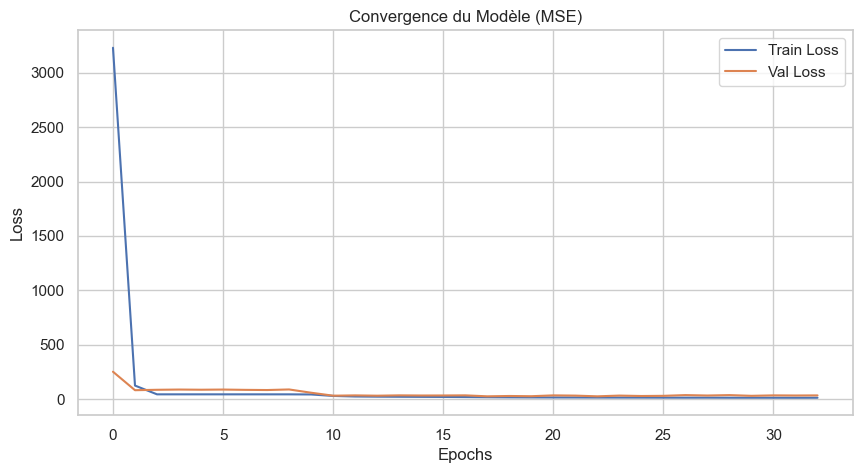

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergence du Modèle (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 📝 Note d'Analyse
Une courbe qui décroît de manière stable et où la perte de validation reste proche de la perte d'entraînement indique une bonne généralisation.

---
## 🚀 8. Perspectives et Améliorations

Pour transformer ce modèle en système industriel, plusieurs actions seraient nécessaires :

### 🔍 A. Ingénierie de Caractéristiques Avancée
L'utilisation uniquement des mesures brutes peut être limitée. Ajouter les **dérivées temporelles** permet de capturer la cinétique de dégradation :
```python
df['dV_dt'] = df['Voltage_measured'].diff() / df['Time'].diff() # Capture la pente de décharge
```

### 🧪 B. Validation Croisée "Leave-One-Battery-Out" (LOBO)
Actuellement, nous testons uniquement sur `B0018`. Une validation robuste effectuerait $N$ entraînements en changeant la batterie de test à chaque fois pour calculer une erreur moyenne plus fiable.

### 🤖 C. Optimisation des Hyperparamètres
L'utilisation de `keras-tuner` permettrait de trouver automatiquement le nombre optimal d'unités LSTM et le taux de dropout.

### 🎯 D. Incertitude Prédictive
L'ajout de couches de Dropout en phase d'inférence (Monte Carlo Dropout) permettrait de fournir un **intervalle de confiance** au lieu d'une valeur unique, ce qui est critique pour les applications de sécurité.

---
### ✅ Fin du Pipeline.